### Middleware

Middleware provides a way to more tighly control what happens inside the agent. Middleware is using for the following:

* Tracking agent behaivior with logging, analytics and debugging
* Transforming prompts, tool selection and output formatting
* Adding retries, fallbacks, and early temination logic
* Applying rate limits, guardrails, and PII detection. 

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] =  os.getenv("GROQ_API_KEY")

### Summerization Middleware

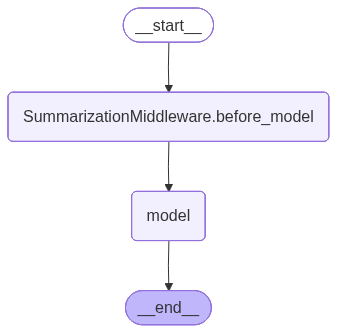

In [2]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

# Agent with messagebased sumerization
agent = create_agent(
    model="groq:qwen/qwen3-32b",
    checkpointer = InMemorySaver(),
    middleware =[
        SummarizationMiddleware(
            model = "groq:qwen/qwen3-32b",
            trigger = ("messages", 10),
            keep = ("messages", 5)
        )

    ]
)
agent

In [3]:
# Thead id
config = {
    "configurable": {"thread_id":"test1"}
}

In [5]:
questions = [
   " what is 2+2?",
   " what is 2*2389?",
   " what is 2-2923?",
   " what is 2429/2?",
   " what is 2+2249?",
   " what is 292-39+2?",

]
for q in questions:
    response = agent.invoke({"messages":[HumanMessage(content=q)]},config=config)
    print(f"Messages:{response}")
    print(f"Messages: {len(response["messages"])}")

Messages:{'messages': [HumanMessage(content=' what is 2+2?', additional_kwargs={}, response_metadata={}, id='7177136d-e991-46cd-b438-0875fa870573'), AIMessage(content='<think>\nOkay, so the question is asking "what is 2+2?" Hmm, that seems straightforward, but let me make sure I\'m not missing anything here. Let me start from the basics. Addition is one of the fundamental operations in arithmetic, right? So when you add two numbers together, you combine their quantities. \n\nAlright, starting with the number 2. If I have two apples and someone gives me two more apples, how many apples do I have in total? That should be four. But wait, maybe I should think about it numerically without the apples. Let\'s visualize it. The number line is a good tool. Starting at 0, if I move two units to the right, that\'s 2. Then moving two more units to the right would bring me to 4. So 2 + 2 would be 4. \n\nBut maybe I should consider different number systems. Like, is this in base 10? Well, the questi

In [20]:

# Agent with token based sumerization
def search_hotel(city : str) -> str:
    """Search hotels- returns long response to use tokens. """
    return f"""Hotels in {city}":
    1. Grand hotel - 5 Star , pool, gym, $350/day
    2. City - 4 Star, business center, $100/day
    3. Budget star - 3 Star , free wifi, $40/day"""

agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools = [search_hotel],
    checkpointer = InMemorySaver(),
    middleware =[
        SummarizationMiddleware(
            model = "groq:qwen/qwen3-32b",
            trigger = ("tokens", 1000),
            keep = ("tokens", 300),
        )

    ]
)
config = {
    "configurable": {"thread_id":"test1"}
}

# Token counter
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 2 # 2 char = 1 token

In [21]:
# Run Test
cities = ["Mumbai", "Delhi", "Kolkata", "Pune", "Jaipur", "Chennai"]
for city in cities:
    response = agent.invoke(
        {
            "messages": [HumanMessage(content=f"find hotels in {city}")]
        },
        config = config
    )
tokens = count_tokens(response["messages"])
print(f"{city}: {tokens} tokens, {len(response["messages"])} Messages")
print(f"{(response["messages"])}")

Chennai: 1975 tokens, 9 Messages
[HumanMessage(content="Here is a summary of the conversation to date:\n\n<think>\nOkay, let's start by understanding the user's main goal here. They want to find hotels in Pune, and the conversation history shows that they've previously asked for hotels in Mumbai, Delhi, and Kolkata. Each time, the same three hotels are listed. The AI seems to be using a tool called search_hotel, and the same results are being repeated for different cities. \n\nFirst, the Session Intent should capture that the user is looking for hotel options in various Indian cities, with Pune being the latest. The main task is to provide these options, possibly to help with booking. \n\nNext, the Summary needs to highlight the pattern of identical hotel listings across cities. The fact that the same three hotels are returned each time might be due to the tool's constraints. The user hasn't selected any hotel yet, so the AI is waiting for further instructions.\n\nArtifacts should list